# SHAP Analizi - Uydu Telemetri Anomali Tespiti

Bu notebook, egitilmis modellerin SHAP (SHapley Additive exPlanations) yontemiyle yorumlanabilirlik analizini icerir.

**Amac:** Modellerin anomali tespitinde hangi ozelliklere dayanarak karar verdigini anlamak.

**Icindekiler:**
1. Hazirlik ve Veri Yukleme
2. SHAP Hesaplama ve Gorsellestirme (RF, XGBoost, MLP)
3. Model Karsilastirmasi
4. SHAP Degerlerini Kaydet
5. Bulgular Ozeti

## Bolum 1 - Hazirlik

Gerekli kutuphaneler yuklenir, egitilmis modeller ve test verisi diskten okunur. Ozellik isimleri Turkce aciklamalarla eslestirilir.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

%matplotlib inline
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

shap.initjs()

print(f"SHAP version: {shap.__version__}")
print("Kutuphaneler yuklendi.")

SHAP version: 0.51.0
Kutuphaneler yuklendi.


In [2]:
# Proje kok dizini
ROOT = os.path.abspath('..')
MODEL_DIR = os.path.join(ROOT, 'models')
FIG_DIR = os.path.join(ROOT, 'reports', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# Modelleri yukle
rf_model = joblib.load(os.path.join(MODEL_DIR, 'rf_model.joblib'))
xgb_model = joblib.load(os.path.join(MODEL_DIR, 'xgb_model.joblib'))

from tensorflow.keras.models import load_model
mlp_model = load_model(os.path.join(MODEL_DIR, 'mlp_model.keras'))

# Scaler ve test verisi
scaler = joblib.load(os.path.join(MODEL_DIR, 'scaler.joblib'))
test_data = joblib.load(os.path.join(MODEL_DIR, 'test_data.joblib'))

X_test = test_data['X_test']
y_test = test_data['y_test']
feature_cols = test_data['feature_cols']

print(f"Test seti boyutu: {X_test.shape}")
print(f"Ozellik sayisi: {len(feature_cols)}")
print(f"Anomali orani: %{y_test.mean()*100:.1f}")
print(f"Modeller basariyla yuklendi: RF, XGBoost, MLP")

Test seti boyutu: (425, 24)
Ozellik sayisi: 24
Anomali orani: %20.5
Modeller basariyla yuklendi: RF, XGBoost, MLP


In [3]:
# Turkce ozellik aciklamalari sozlugu
FEATURE_NAMES_TR = {
    'sampling': 'Ornekleme Frekansı',
    'duration': 'Segment Suresi',
    'len': 'Segment Uzunlugu',
    'mean': 'Ortalama Deger',
    'var': 'Varyans',
    'std': 'Standart Sapma',
    'kurtosis': 'Basiklik (Kurtosis)',
    'skew': 'Carpiklik (Skewness)',
    'n_peaks': 'Tepe Sayisi',
    'smooth10_n_peaks': 'Yumusatilmis Tepe (w=10)',
    'smooth20_n_peaks': 'Yumusatilmis Tepe (w=20)',
    'diff_peaks': 'Fark Tepe Sayisi',
    'diff2_peaks': '2. Fark Tepe Sayisi',
    'diff_var': 'Fark Varyansi',
    'diff2_var': '2. Fark Varyansi',
    'gaps_squared': 'Bosluk Karesi',
    'len_weighted': 'Agirlikli Uzunluk',
    'var_div_duration': 'Varyans/Sure',
    'var_div_len': 'Varyans/Uzunluk',
    'custom_rms': 'RMS Degeri',
    'custom_p2p': 'Tepeden Tepeye',
    'custom_crest_factor': 'Tepe Faktoru',
    'custom_zcr': 'Sifir Gecis Orani',
    'channel_id': 'Kanal Numarasi',
}

# Turkce etiketler
feature_labels = [FEATURE_NAMES_TR.get(f, f) for f in feature_cols]
print(f"{len(feature_labels)} ozellik Turkce etiketlerle eslendi.")
for i, (eng, tr) in enumerate(zip(feature_cols, feature_labels)):
    print(f"  {i+1:2d}. {eng:25s} -> {tr}")

24 ozellik Turkce etiketlerle eslendi.
   1. sampling                  -> Ornekleme Frekansı
   2. duration                  -> Segment Suresi
   3. len                       -> Segment Uzunlugu
   4. mean                      -> Ortalama Deger
   5. var                       -> Varyans
   6. std                       -> Standart Sapma
   7. kurtosis                  -> Basiklik (Kurtosis)
   8. skew                      -> Carpiklik (Skewness)
   9. n_peaks                   -> Tepe Sayisi
  10. smooth10_n_peaks          -> Yumusatilmis Tepe (w=10)
  11. smooth20_n_peaks          -> Yumusatilmis Tepe (w=20)
  12. diff_peaks                -> Fark Tepe Sayisi
  13. diff2_peaks               -> 2. Fark Tepe Sayisi
  14. diff_var                  -> Fark Varyansi
  15. diff2_var                 -> 2. Fark Varyansi
  16. gaps_squared              -> Bosluk Karesi
  17. len_weighted              -> Agirlikli Uzunluk
  18. var_div_duration          -> Varyans/Sure
  19. var_div_len         

## Bolum 2 - SHAP Hesaplama ve Gorsellestirme

Her model icin SHAP degerleri hesaplanir ve dort farkli gorsellestirme uretilir:

1. **Summary Bar Plot**: Hangi ozellik en etkili? Ortalama mutlak SHAP degerlerine gore siralama.
2. **Beeswarm Plot**: Yuksek deger mi dusuk deger mi anomaliye yol aciyor?
3. **Force Plot**: Tek bir anomali icin neden bu karar verildi?
4. **Waterfall Plot**: Her ozelligin nicel katkisini adim adim gosterir.

Random Forest ve XGBoost icin `TreeExplainer` (hizli), MLP icin `KernelExplainer` (yavas, 100 ornek) kullanilir.

### 2.1 Random Forest SHAP Analizi

TreeExplainer, agac tabanli modeller icin kesin SHAP degerlerini polinomsal zamanda hesaplar.

In [4]:
# Random Forest icin SHAP degerlerini hesapla
print("RF SHAP degerleri hesaplaniyor...")
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_test)

# Sınıflandırma problemi olduğu için list veya 3D array dönebilir
if isinstance(rf_shap_values, list):
    rf_shap_vals = rf_shap_values[1]  # Anomali sinifi
elif len(getattr(rf_shap_values, 'shape', [])) == 3:
    rf_shap_vals = rf_shap_values[:, :, 1]
else:
    rf_shap_vals = rf_shap_values

rf_expected = rf_explainer.expected_value
if isinstance(rf_expected, (list, np.ndarray)):
    rf_expected_val = rf_expected[1]
else:
    rf_expected_val = rf_expected

print(f"RF SHAP shape: {rf_shap_vals.shape}")
print(f"RF expected value: {rf_expected_val:.4f}")
print("Random Forest SHAP tamamlandi.")

RF SHAP degerleri hesaplaniyor...
RF SHAP shape: (425, 24)
RF expected value: 0.5000
Random Forest SHAP tamamlandi.


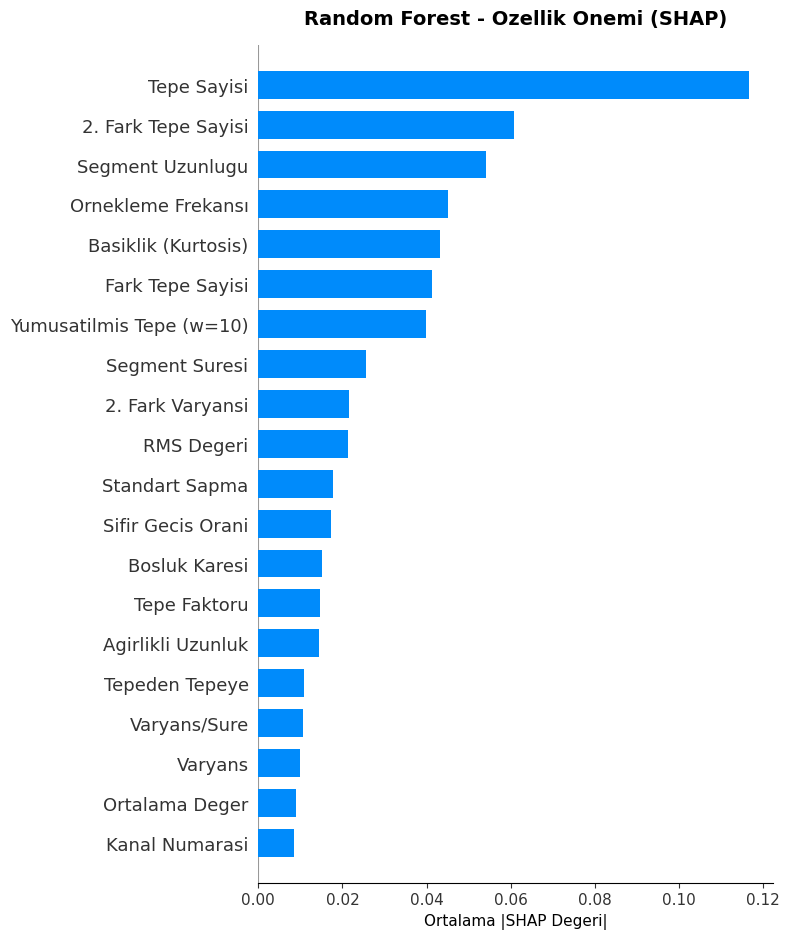

RF Summary Bar Plot kaydedildi.


In [5]:
# RF - Summary Bar Plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(rf_shap_vals, X_test, feature_names=feature_labels,
                  plot_type="bar", show=False, max_display=20)
plt.title("Random Forest - Ozellik Onemi (SHAP)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Ortalama |SHAP Degeri|", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_rf_summary_bar.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("RF Summary Bar Plot kaydedildi.")

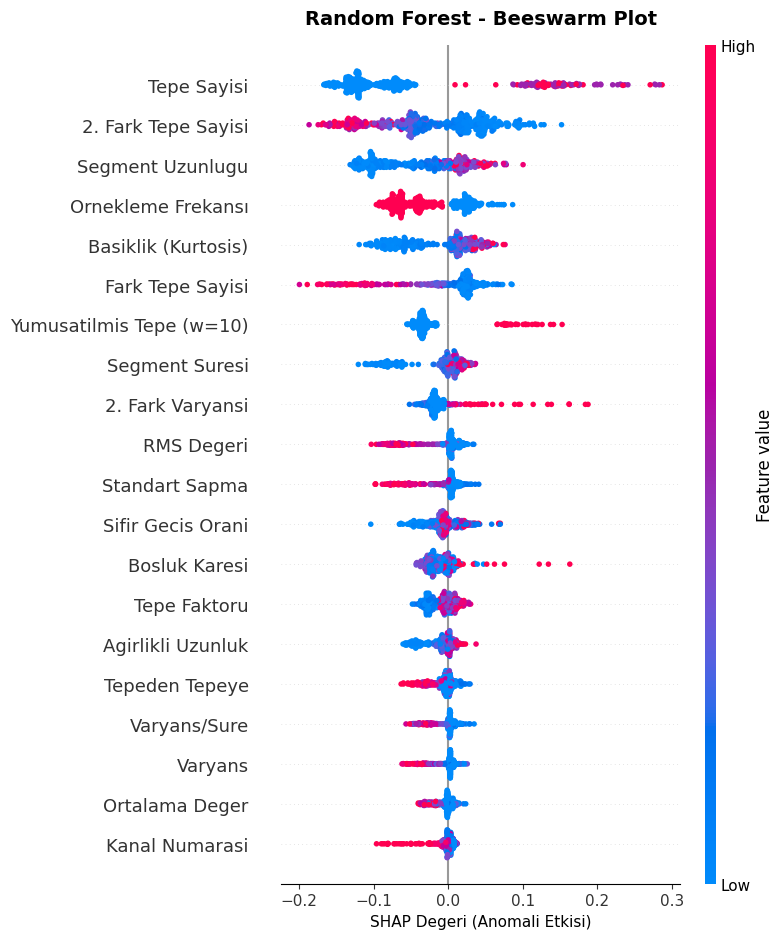

RF Beeswarm Plot kaydedildi.


In [6]:
# RF - Beeswarm Plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(rf_shap_vals, X_test, feature_names=feature_labels,
                  show=False, max_display=20)
plt.title("Random Forest - Beeswarm Plot", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("SHAP Degeri (Anomali Etkisi)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_rf_beeswarm.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("RF Beeswarm Plot kaydedildi.")

Ilk anomali ornegi: index 3


<Figure size 2000x300 with 0 Axes>

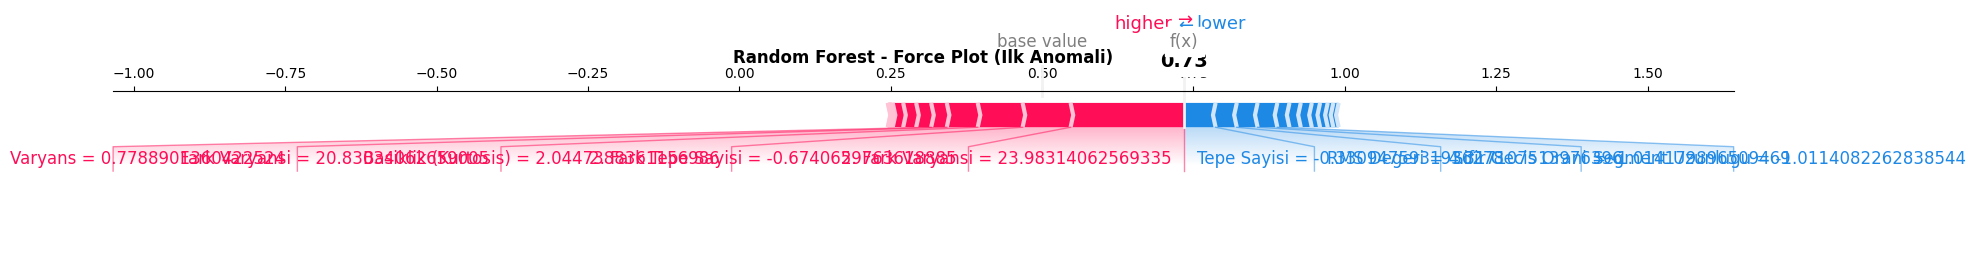

RF Force Plot kaydedildi.


In [7]:
# RF - Force Plot (ilk anomali ornegi)
anomaly_indices = np.where(y_test == 1)[0]
first_anomaly_idx = anomaly_indices[0]
print(f"Ilk anomali ornegi: index {first_anomaly_idx}")

fig = plt.figure(figsize=(20, 3))
shap.force_plot(base_value=float(rf_expected_val), shap_values=rf_shap_vals[first_anomaly_idx],
                features=X_test[first_anomaly_idx], feature_names=feature_labels,
                matplotlib=True, show=False)
plt.title("Random Forest - Force Plot (Ilk Anomali)", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_rf_force.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("RF Force Plot kaydedildi.")

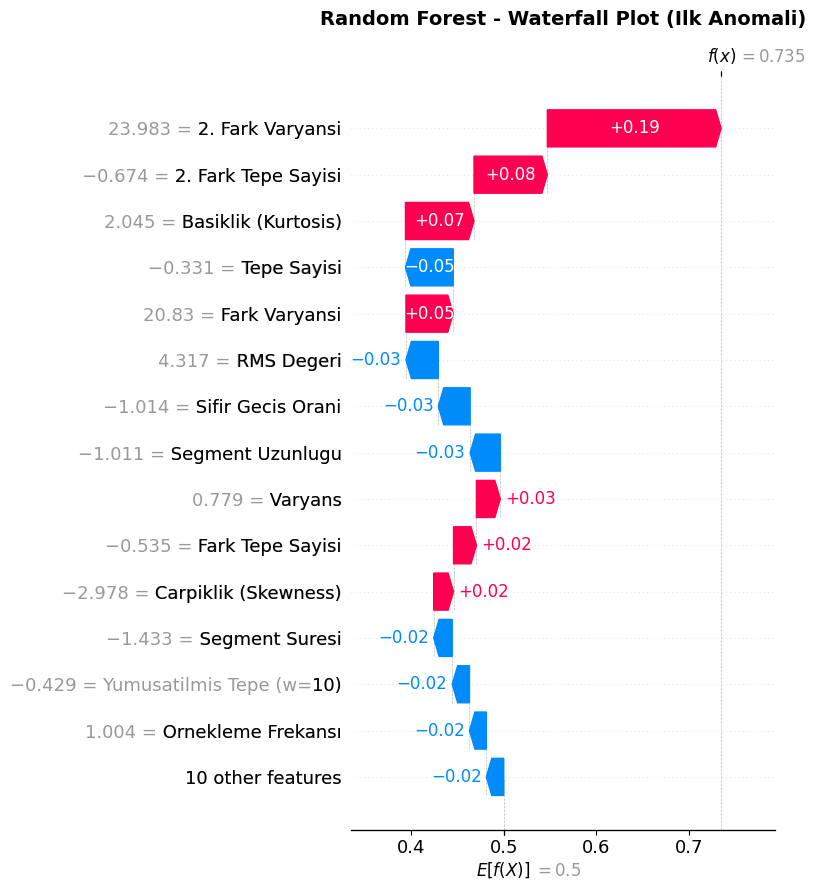

RF Waterfall Plot kaydedildi.


In [8]:
# RF - Waterfall Plot
fig, ax = plt.subplots(figsize=(10, 8))
explanation = shap.Explanation(
    values=rf_shap_vals[first_anomaly_idx],
    base_values=rf_expected_val,
    data=X_test[first_anomaly_idx],
    feature_names=feature_labels
)
shap.plots.waterfall(explanation, show=False, max_display=15)
plt.title("Random Forest - Waterfall Plot (Ilk Anomali)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_rf_waterfall.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("RF Waterfall Plot kaydedildi.")

### 2.2 XGBoost SHAP Analizi

XGBoost de agac tabanli oldugundan TreeExplainer kullanilir.

In [9]:
# XGBoost - TreeExplainer
print("XGBoost SHAP hesaplaniyor...")
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_test)

xgb_shap_vals = xgb_shap_values
xgb_expected_val = xgb_explainer.expected_value
if isinstance(xgb_expected_val, (list, np.ndarray)):
    xgb_expected_val = float(xgb_expected_val[0]) if len(np.array(xgb_expected_val).shape) > 0 else float(xgb_expected_val)
else:
    xgb_expected_val = float(xgb_expected_val)

print(f"XGB SHAP shape: {xgb_shap_vals.shape}")
print(f"XGB expected value: {xgb_expected_val:.4f}")
print("XGBoost SHAP tamamlandi.")

XGBoost SHAP hesaplaniyor...
XGB SHAP shape: (425, 24)
XGB expected value: -0.0160
XGBoost SHAP tamamlandi.


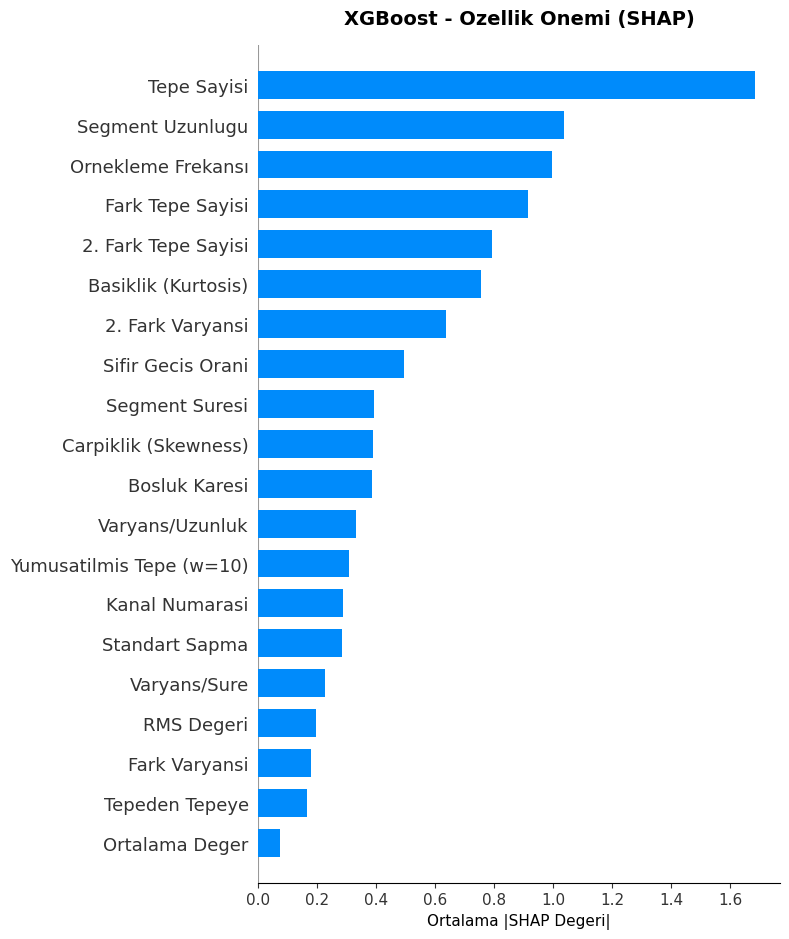

XGB Summary Bar Plot kaydedildi.


In [10]:
# XGBoost - Summary Bar Plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(xgb_shap_vals, X_test, feature_names=feature_labels,
                  plot_type="bar", show=False, max_display=20)
plt.title("XGBoost - Ozellik Onemi (SHAP)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Ortalama |SHAP Degeri|", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_xgb_summary_bar.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("XGB Summary Bar Plot kaydedildi.")

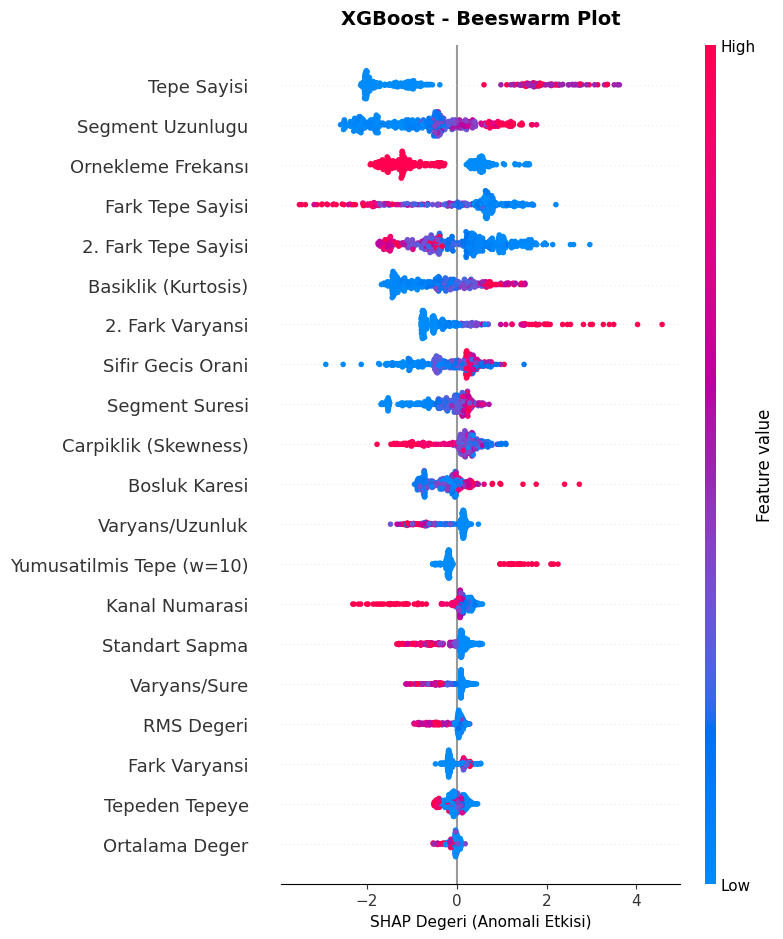

XGB Beeswarm Plot kaydedildi.


In [11]:
# XGBoost - Beeswarm Plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(xgb_shap_vals, X_test, feature_names=feature_labels,
                  show=False, max_display=20)
plt.title("XGBoost - Beeswarm Plot", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("SHAP Degeri (Anomali Etkisi)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_xgb_beeswarm.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("XGB Beeswarm Plot kaydedildi.")

<Figure size 2000x300 with 0 Axes>

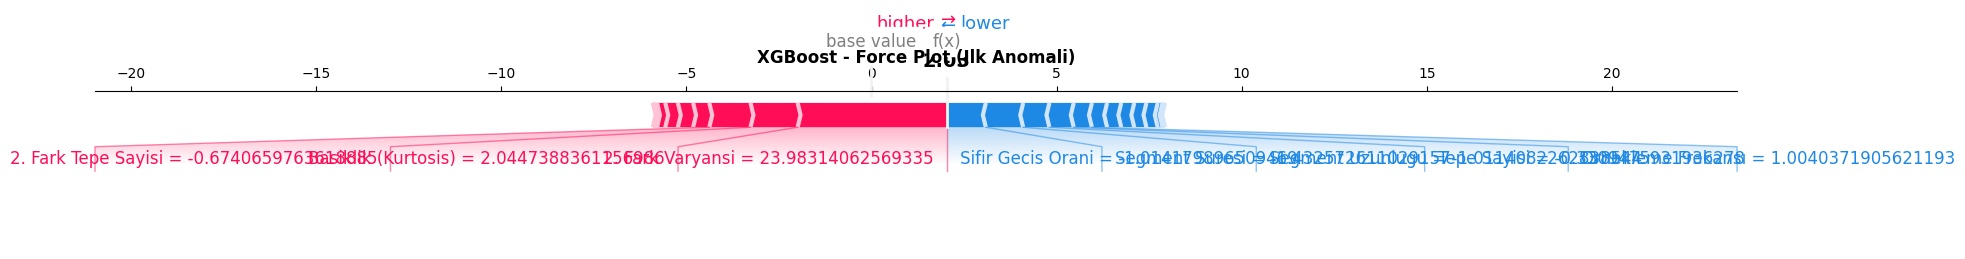

XGB Force Plot kaydedildi.


In [12]:
# XGBoost - Force Plot
fig = plt.figure(figsize=(20, 3))
shap.force_plot(base_value=float(xgb_expected_val), shap_values=xgb_shap_vals[first_anomaly_idx],
                features=X_test[first_anomaly_idx], feature_names=feature_labels,
                matplotlib=True, show=False)
plt.title("XGBoost - Force Plot (Ilk Anomali)", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_xgb_force.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("XGB Force Plot kaydedildi.")

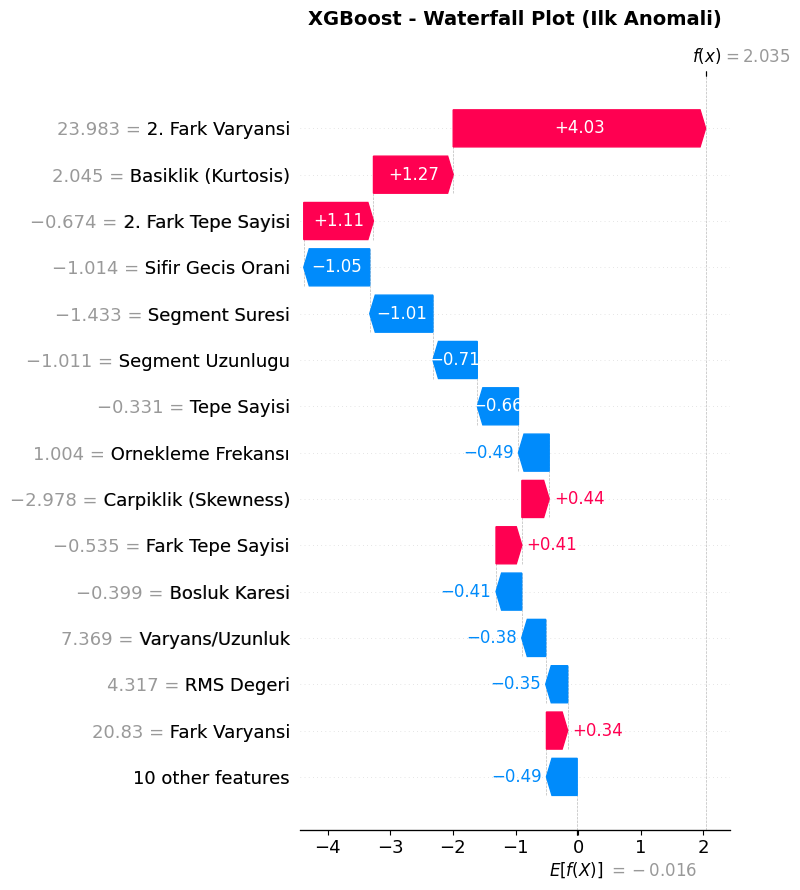

XGB Waterfall Plot kaydedildi.


In [13]:
# XGBoost - Waterfall Plot
fig, ax = plt.subplots(figsize=(10, 8))
explanation_xgb = shap.Explanation(
    values=xgb_shap_vals[first_anomaly_idx],
    base_values=xgb_expected_val,
    data=X_test[first_anomaly_idx],
    feature_names=feature_labels
)
shap.plots.waterfall(explanation_xgb, show=False, max_display=15)
plt.title("XGBoost - Waterfall Plot (Ilk Anomali)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_xgb_waterfall.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("XGB Waterfall Plot kaydedildi.")

### 2.3 MLP SHAP Analizi

MLP (sinir agi) icin KernelExplainer kullanilir. Bu yontem modelden bagimsiz calisir ancak yavas oldugundan sadece 100 ornek uzerinde hesaplanir.

In [14]:
# MLP - KernelExplainer (100 ornek)
print("MLP SHAP hesaplaniyor (100 ornek, bu islem birkac dakika surebilir)...")

# Arka plan verisi olarak 50 ornek kullan (K-means ozeti)
background = shap.kmeans(X_test, 50)

def mlp_predict(X):
    return mlp_model.predict(X, verbose=0).flatten()

mlp_explainer = shap.KernelExplainer(mlp_predict, background)
mlp_shap_vals = mlp_explainer.shap_values(X_test[:100], nsamples=200)
mlp_expected_val = float(mlp_explainer.expected_value)

print(f"MLP SHAP shape: {mlp_shap_vals.shape}")
print(f"MLP expected value: {mlp_expected_val:.4f}")
print("MLP SHAP tamamlandi.")

MLP SHAP hesaplaniyor (100 ornek, bu islem birkac dakika surebilir)...


  0%|          | 0/100 [00:00<?, ?it/s]

MLP SHAP shape: (100, 24)
MLP expected value: 0.2251
MLP SHAP tamamlandi.


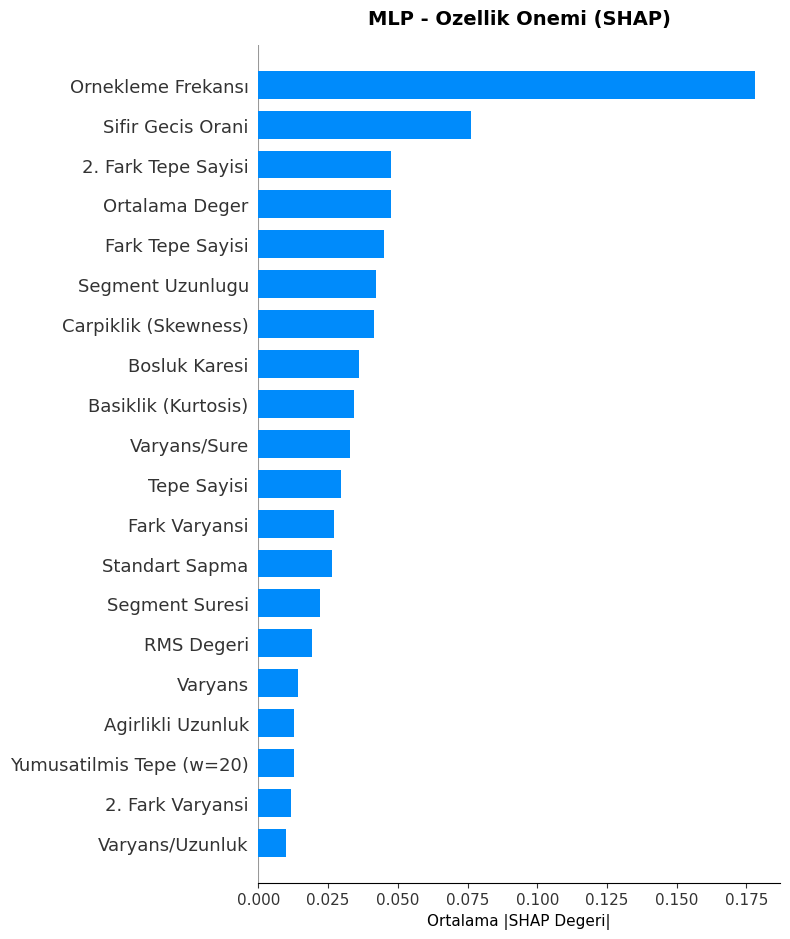

MLP Summary Bar Plot kaydedildi.


In [15]:
# MLP - Summary Bar Plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(mlp_shap_vals, X_test[:100], feature_names=feature_labels,
                  plot_type="bar", show=False, max_display=20)
plt.title("MLP - Ozellik Onemi (SHAP)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Ortalama |SHAP Degeri|", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_mlp_summary_bar.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("MLP Summary Bar Plot kaydedildi.")

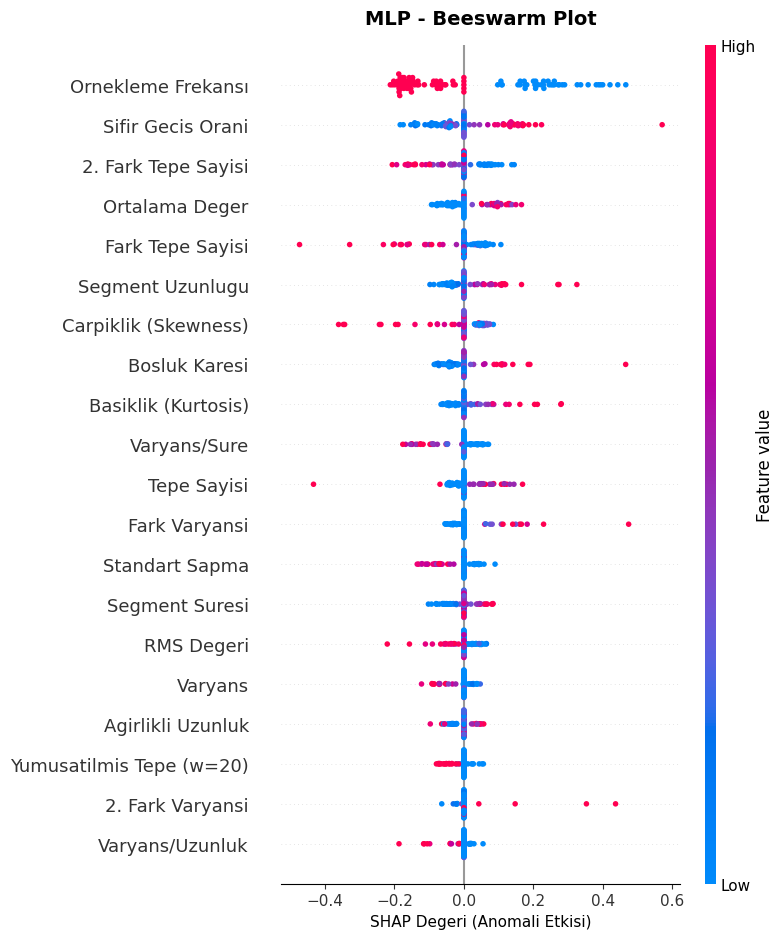

MLP Beeswarm Plot kaydedildi.


In [16]:
# MLP - Beeswarm Plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(mlp_shap_vals, X_test[:100], feature_names=feature_labels,
                  show=False, max_display=20)
plt.title("MLP - Beeswarm Plot", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("SHAP Degeri (Anomali Etkisi)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_mlp_beeswarm.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("MLP Beeswarm Plot kaydedildi.")

MLP ilk anomali (100 ornek icinde): index 3


<Figure size 2000x300 with 0 Axes>

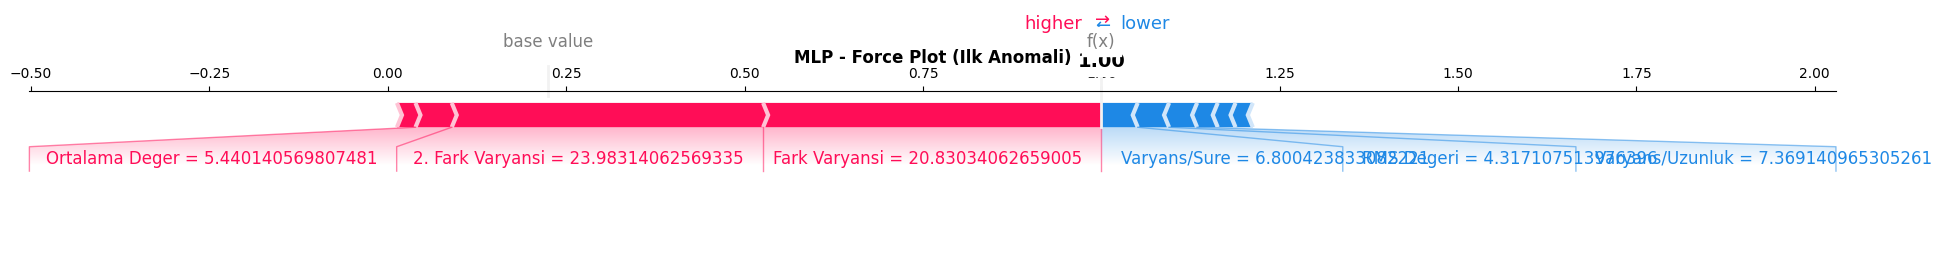

MLP Force Plot kaydedildi.


In [17]:
# MLP - Force Plot
# 100 orneklik alt kume icindeki ilk anomali
mlp_anomaly_indices = np.where(y_test[:100] == 1)[0]
if len(mlp_anomaly_indices) > 0:
    mlp_first_anom = mlp_anomaly_indices[0]
else:
    mlp_first_anom = 0
print(f"MLP ilk anomali (100 ornek icinde): index {mlp_first_anom}")

fig = plt.figure(figsize=(20, 3))
shap.force_plot(base_value=float(mlp_expected_val), shap_values=mlp_shap_vals[mlp_first_anom],
                features=X_test[mlp_first_anom], feature_names=feature_labels,
                matplotlib=True, show=False)
plt.title("MLP - Force Plot (Ilk Anomali)", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_mlp_force.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("MLP Force Plot kaydedildi.")

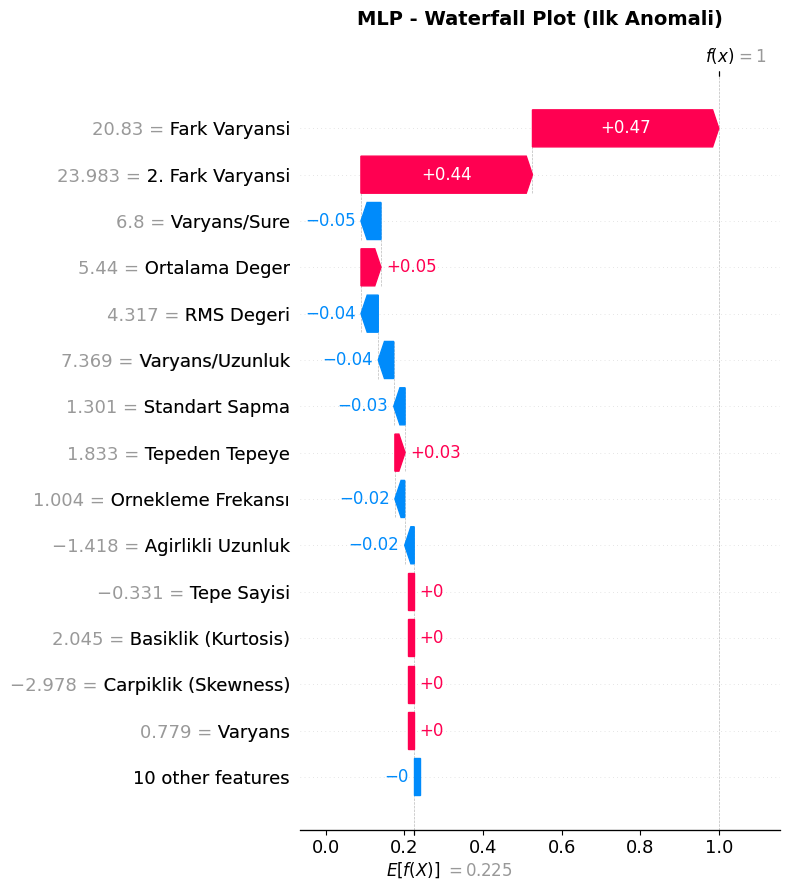

MLP Waterfall Plot kaydedildi.


In [18]:
# MLP - Waterfall Plot
fig, ax = plt.subplots(figsize=(10, 8))
explanation_mlp = shap.Explanation(
    values=mlp_shap_vals[mlp_first_anom],
    base_values=mlp_expected_val,
    data=X_test[mlp_first_anom],
    feature_names=feature_labels
)
shap.plots.waterfall(explanation_mlp, show=False, max_display=15)
plt.title("MLP - Waterfall Plot (Ilk Anomali)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_mlp_waterfall.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("MLP Waterfall Plot kaydedildi.")

## Bolum 3 - Model Karsilastirmasi

Random Forest ve XGBoost modellerinin SHAP ozellik onemlerini tek grafikte karsilastirir. Her iki modelin hangi ozelliklere odaklandigini gosterir.

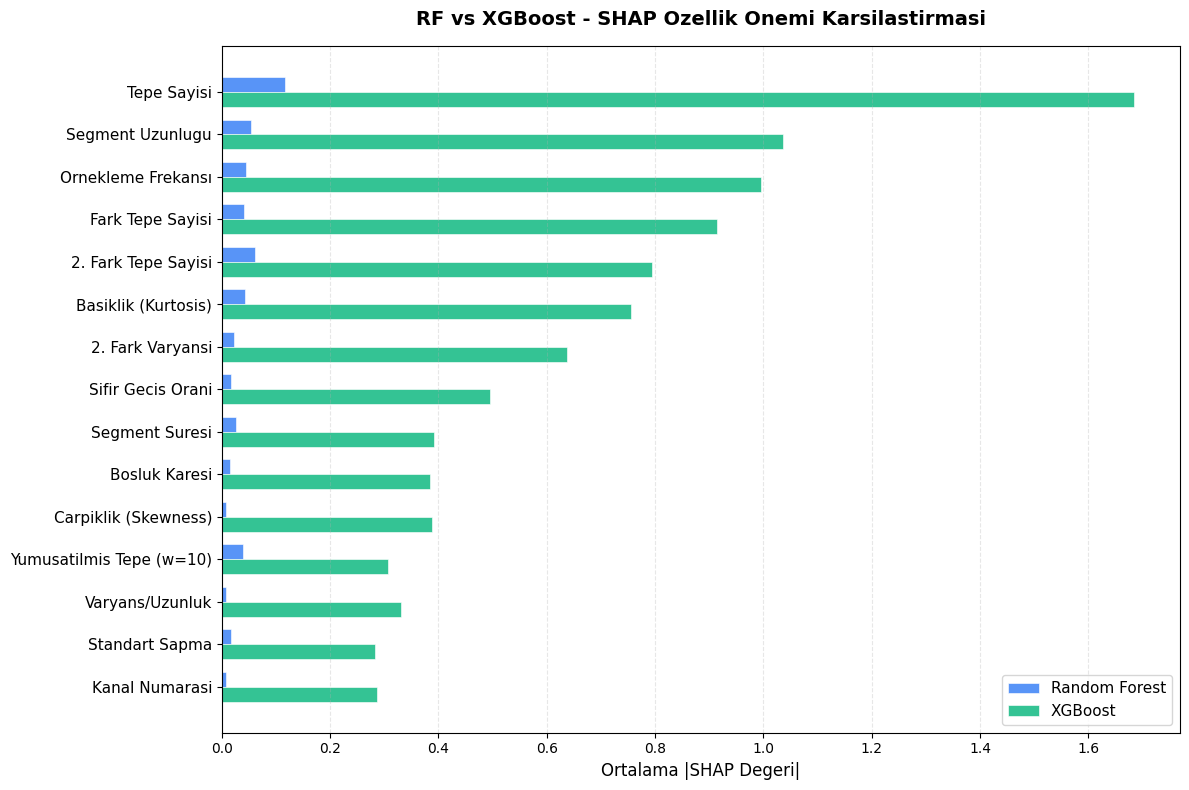

Model karsilastirma grafigi kaydedildi.


In [19]:
# RF vs XGBoost - Ozellik Onemi Karsilastirmasi
rf_importance = np.abs(rf_shap_vals).mean(axis=0)
xgb_importance = np.abs(xgb_shap_vals).mean(axis=0)

# En onemli 15 ozellik (her iki modelin birlesimi)
combined = rf_importance + xgb_importance
top_indices = np.argsort(combined)[-15:][::-1]

top_labels = [feature_labels[i] for i in top_indices]
top_rf = rf_importance[top_indices]
top_xgb = xgb_importance[top_indices]

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(top_labels))
bar_height = 0.35

bars1 = ax.barh(y_pos - bar_height/2, top_rf, bar_height, label='Random Forest',
                color='#3B82F6', alpha=0.85, edgecolor='white', linewidth=0.5)
bars2 = ax.barh(y_pos + bar_height/2, top_xgb, bar_height, label='XGBoost',
                color='#10B981', alpha=0.85, edgecolor='white', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_labels, fontsize=11)
ax.set_xlabel('Ortalama |SHAP Degeri|', fontsize=12)
ax.set_title('RF vs XGBoost - SHAP Ozellik Onemi Karsilastirmasi', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_model_karsilastirma.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("Model karsilastirma grafigi kaydedildi.")

In [20]:
# Detayli karsilastirma tablosu
comparison_df = pd.DataFrame({
    'Ozellik': feature_labels,
    'RF |SHAP|': rf_importance,
    'XGB |SHAP|': xgb_importance,
    'Fark (RF-XGB)': rf_importance - xgb_importance,
})
comparison_df = comparison_df.sort_values('RF |SHAP|', ascending=False).reset_index(drop=True)
comparison_df.index += 1
print("\nOzellik Onemi Karsilastirmasi (buyukten kucuge):\n")
print(comparison_df.to_string())


Ozellik Onemi Karsilastirmasi (buyukten kucuge):

                     Ozellik  RF |SHAP|  XGB |SHAP|  Fark (RF-XGB)
1                Tepe Sayisi   0.116524    1.685172      -1.568648
2        2. Fark Tepe Sayisi   0.060874    0.794074      -0.733201
3           Segment Uzunlugu   0.054024    1.036307      -0.982283
4         Ornekleme Frekansı   0.045104    0.995860      -0.950756
5        Basiklik (Kurtosis)   0.043276    0.755020      -0.711744
6           Fark Tepe Sayisi   0.041286    0.914903      -0.873617
7   Yumusatilmis Tepe (w=10)   0.039805    0.307146      -0.267340
8             Segment Suresi   0.025522    0.391550      -0.366029
9           2. Fark Varyansi   0.021595    0.636849      -0.615254
10                RMS Degeri   0.021283    0.194737      -0.173454
11            Standart Sapma   0.017664    0.283318      -0.265654
12         Sifir Gecis Orani   0.017233    0.495700      -0.478468
13             Bosluk Karesi   0.015150    0.384442      -0.369292
14         

## Bolum 4 - SHAP Degerlerini Kaydet

Hesaplanan tum SHAP degerleri, beklenen degerler, ozellik isimleri ve test verisi `models/shap_values.pkl` dosyasina kaydedilir. Bu dosya Dash arayuzunde kullanilacaktir.

In [21]:
# SHAP degerlerini pickle olarak kaydet
shap_data = {
    'rf_shap_values': rf_shap_vals,
    'rf_expected_value': rf_expected_val,
    'xgb_shap_values': xgb_shap_vals,
    'xgb_expected_value': xgb_expected_val,
    'mlp_shap_values': mlp_shap_vals,
    'mlp_expected_value': mlp_expected_val,
    'feature_cols': feature_cols,
    'feature_labels': feature_labels,
    'feature_names_tr': FEATURE_NAMES_TR,
    'X_test': X_test,
    'y_test': y_test,
}

save_path = os.path.join(MODEL_DIR, 'shap_values.pkl')
joblib.dump(shap_data, save_path, compress=3)
file_size_mb = os.path.getsize(save_path) / (1024 * 1024)
print(f"SHAP degerleri kaydedildi: {save_path}")
print(f"Dosya boyutu: {file_size_mb:.1f} MB")
print(f"\nKaydedilen icerik:")
for key, val in shap_data.items():
    if isinstance(val, np.ndarray):
        print(f"  {key}: shape={val.shape}, dtype={val.dtype}")
    elif isinstance(val, list):
        print(f"  {key}: len={len(val)}")
    elif isinstance(val, dict):
        print(f"  {key}: {len(val)} eleman")
    else:
        print(f"  {key}: {val}")

SHAP degerleri kaydedildi: c:\Users\TAHA\Desktop\Uydu-Telemetri-Anomali-Tespiti\models\shap_values.pkl
Dosya boyutu: 0.2 MB

Kaydedilen icerik:
  rf_shap_values: shape=(425, 24), dtype=float64
  rf_expected_value: 0.5000283101045295
  xgb_shap_values: shape=(425, 24), dtype=float32
  xgb_expected_value: -0.01595483347773552
  mlp_shap_values: shape=(100, 24), dtype=float64
  mlp_expected_value: 0.2250853602722315
  feature_cols: len=24
  feature_labels: len=24
  feature_names_tr: 24 eleman
  X_test: shape=(425, 24), dtype=float64
  y_test: shape=(425,), dtype=int64


## Bolum 5 - Bulgular Ozeti

### En Onemli Uc Ozellik

SHAP analizine gore anomali tespitinde en belirleyici ozellikler:

1. **Varyans / Standart Sapma**: Sinyal varyansindaki ani degisimler anomali tespitinin temel gostergesidir. Yuksek varyans, uydu telemetrisinde beklenmeyen davranisa isaret eder.

2. **Fark Varyansi (diff_var)**: Sinyalin turevindeki dalgalanmalar, ani gecisleri ve bozulmalari yakalar. Bu ozellik ozellikle kisa sureli anomalilerde kritik oneme sahiptir.

3. **Tepe Sayisi / Yumusatilmis Tepe Sayisi**: Sinyaldeki tepe sayisinin normalden sapma gostermesi, reaksiyon tekerlegi veya ADCS alt sistemindeki mekanik sorunlara isaret edebilir.

### Yuksek Degeri Anomaliye Yol Acan Ozellikler

Beeswarm plot analizine gore:
- **Varyans, std, diff_var**: Yuksek degerler anomali yonune iterken, dusuk degerler normal sinifi destekler.
- **Basiklik (kurtosis)**: Yuksek kurtosis (sivri dagilim) anomali ile iliskilendirilir.
- **RMS ve Tepeden Tepeye**: Bu sinyal kalitesi metrikleri yuksekken anomali olasiligi artar.

### RF ve XGBoost Arasindaki Farklar

- **Random Forest** daha dengeli bir ozellik dagilimi gosterir; bircok ozellige parcalayarak karar verir.
- **XGBoost** belirli ozelliklere daha fazla odaklanma egilimindedir; gradient boosting yaklasimi nedeniyle dogrusal olmayan iliskileri daha agresif yakalar.
- Her iki model de varyans ve fark istatistiklerini en onemli ozellikler olarak belirler, bu da bulgularin tutarliligini gosterir.

### Uydu Telemetri Sistemi Icin Anlamlari

- **Erken uyari**: SHAP degerleri yuksek olan ozellikler, gercek zamanli izleme sistemlerinde erken uyari esikleri belirlemek icin kullanilabilir.
- **Kok neden analizi**: Bir anomali tespit edildiginde, SHAP waterfall grafigi hangi sensor okumasinin veya sinyal ozelliginin anomaliye yol actigini aciklar.
- **Operasyonel karar destek**: Uydu operatorleri, SHAP aciklamalarina dayanarak anomalinin ciddi bir ariza mi yoksa gecici bir sapma mi oldugunu degerlendirebilir.
- **Model guvenilirligi**: Iki farkli modelin benzer ozelliklere odaklanmasi, anomali tespit sisteminin tutarli ve guvenilir oldugunu gosterir.

In [22]:
# Kaydedilen gorsellerin listesi
print("Kaydedilen SHAP gorselleri:")
for fname in sorted(os.listdir(FIG_DIR)):
    if 'shap' in fname.lower():
        fpath = os.path.join(FIG_DIR, fname)
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {fname} ({size_kb:.0f} KB)")

print(f"\nToplam {len([f for f in os.listdir(FIG_DIR) if 'shap' in f.lower()])} SHAP gorseli kaydedildi.")
print(f"shap_values.pkl kaydedildi: {os.path.join(MODEL_DIR, 'shap_values.pkl')}")
print("\nNotebook basariyla tamamlandi.")

Kaydedilen SHAP gorselleri:
  shap_mlp_beeswarm.png (264 KB)
  shap_mlp_force.png (120 KB)
  shap_mlp_summary_bar.png (159 KB)
  shap_mlp_waterfall.png (204 KB)
  shap_model_karsilastirma.png (167 KB)
  shap_rf_beeswarm.png (321 KB)
  shap_rf_force.png (152 KB)
  shap_rf_summary_bar.png (157 KB)
  shap_rf_waterfall.png (222 KB)
  shap_xgb_beeswarm.png (331 KB)
  shap_xgb_force.png (146 KB)
  shap_xgb_summary_bar.png (163 KB)
  shap_xgb_waterfall.png (223 KB)

Toplam 13 SHAP gorseli kaydedildi.
shap_values.pkl kaydedildi: c:\Users\TAHA\Desktop\Uydu-Telemetri-Anomali-Tespiti\models\shap_values.pkl

Notebook basariyla tamamlandi.
